In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import yfinance as yf
import os
import pandas as pd

O próximo dataframe é esse: um histórico de preços do bitcoin em todo o período que vamos analisar.

In [3]:
btc_ticker = yf.Ticker("BTC-USD") # pegar o ticker do Bitcoin em dólares
btc = btc_ticker.history(period="max") # pegar o histórico completo de preços

In [4]:
btc # vizualizar o que temos:

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...
2026-01-13 00:00:00+00:00,91185.335938,96011.625000,90941.929688,95321.781250,54980674354,0.0,0.0
2026-01-14 00:00:00+00:00,95322.906250,97860.601562,94583.046875,96929.328125,60592490863,0.0,0.0
2026-01-15 00:00:00+00:00,96931.289062,97150.171875,95103.242188,95551.187500,53086363027,0.0,0.0


In [5]:
btc.index = pd.to_datetime(btc.index) # garantir que o índice de datas esteja no formato datetime

In [6]:
del btc["Dividends"] # remover a coluna de dividendos, que não é relevante para o Bitcoin
del btc["Stock Splits"] # remover a coluna de splits de ações, que também não é relevante
btc.columns = [c.lower() for c in btc.columns] # converter os nomes das colunas para minúsculas para consistência. Só porque é chato de lidar.

In [7]:
!pip install matplotlib # vamos vizualizar agora

Defaulting to user installation because normal site-packages is not writeable


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Text(0.5, 1.0, 'Bitcoin Price Over Time')

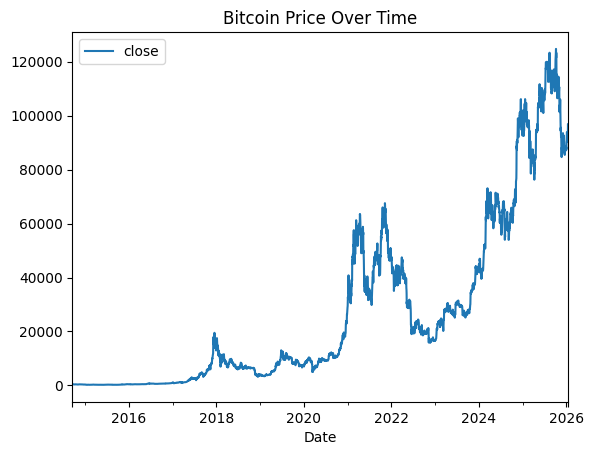

In [8]:
import matplotlib.pyplot as plt
btc.plot.line(y="close", use_index=True) # aqui vemos o preço de fechamento do Bitcoin ao longo do tempo
plt.title("Bitcoin Price Over Time")

Agora precisamos combinar os dois datasets

In [9]:
from pathlib import Path

p = Path("C:/Users/hulkd/OneDrive/Documents/Docs estudo/Projetos/Machine Learning/Projeto Bitcoin/Desenvolvimento/Introdução_a_Machine_Learning/Parte 2/wikipedia_edits.csv")

print("Existe?", p.exists())
print("É arquivo?", p.is_file())
print("Caminho absoluto:", p.resolve())


Existe? True
É arquivo? True
Caminho absoluto: C:\Users\hulkd\OneDrive\Documents\Docs estudo\Projetos\Machine Learning\Projeto Bitcoin\Desenvolvimento\Introdução_a_Machine_Learning\Parte 2\wikipedia_edits.csv


In [10]:
wiki = pd.read_csv('wikipedia_edits.csv', index_col=0, parse_dates=True)


In [11]:
wiki

,edit_count,sentiment,neg_sentiment
2010-07-14,1.0,0.296861,0.300000
2010-07-15,1.0,0.296696,0.300000
2010-07-16,1.0,0.304687,0.300000
2010-07-18,1.0,0.291848,0.300000
2010-07-19,1.0,0.289746,0.300000
...,...,...,...
2025-11-18,1.0,0.216875,0.366667
2025-11-22,1.0,0.282193,0.333333
2025-11-23,1.0,0.216004,0.366667
2025-11-26,1.0,0.222128,0.366667


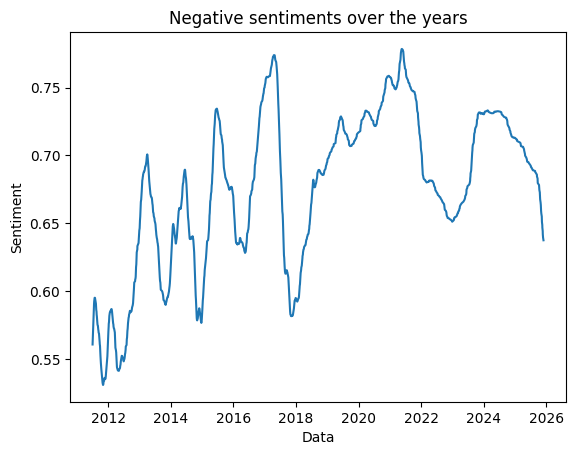

In [12]:
wiki.index = pd.to_datetime(wiki.index)

plt.figure()
plt.plot(wiki.index, wiki['neg_sentiment'].rolling(180).mean())
plt.title('Negative sentiments over the years')
plt.xlabel('Data')
plt.ylabel('Sentiment')
plt.show()

Dá pra perceber que de 202-2024 teve muitos sentimentos negativos. Antes do período de consolidação (antes do boom) ele tinha muitas variações. Após 2018 ele tem sentimentos bem mais lineares, o que indica a consolidação da moeda no mercado. Ela foi uma data seguida de uma grande curva, até o real período de alta (2024).

In [13]:
btc.index = btc.index.tz_convert('UTC') if btc.index.tz is not None else btc.index.tz_localize('UTC')
wiki.index = wiki.index.tz_convert('UTC') if wiki.index.tz is not None else wiki.index.tz_localize('UTC')

# mesclar:
btc = btc.merge(wiki, left_index=True, right_index=True) # left_index e right_index indicam que queremos mesclar com base nos índices de ambos os dataframes (é tipo o left/right join do SQL)
btc

,open,high,low,close,volume,edit_count,sentiment,neg_sentiment
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,1.0,-0.174351,0.566667
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,1.0,-0.174023,0.566667
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,1.0,-0.172224,0.566667
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,1.0,-0.166161,0.566667
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,1.0,-0.108003,0.533333
...,...,...,...,...,...,...,...,...
2025-11-18 00:00:00+00:00,92094.531250,93745.078125,89300.460938,92948.875000,101333569062,1.0,0.216875,0.366667
2025-11-22 00:00:00+00:00,85098.562500,85503.007812,83490.898438,84648.359375,40793099246,1.0,0.282193,0.333333
2025-11-23 00:00:00+00:00,84648.609375,88038.468750,84641.773438,86805.007812,58083435576,1.0,0.216004,0.366667
2025-11-26 00:00:00+00:00,87345.585938,90581.156250,86316.898438,90518.367188,66496301869,1.0,0.222128,0.366667


Agora precisamos decidir o que prever. 
Vamos prever o seguinte: "O preço vai subir ou descer amanhã?"

In [14]:
btc["tomorrow"] = btc["close"].shift(-1)
btc

,open,high,low,close,volume,edit_count,sentiment,neg_sentiment,tomorrow
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,1.0,-0.174351,0.566667,424.440002
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,1.0,-0.174023,0.566667,394.795990
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,1.0,-0.172224,0.566667,408.903992
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,1.0,-0.166161,0.566667,398.821014
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,1.0,-0.108003,0.533333,435.790985
...,...,...,...,...,...,...,...,...,...
2025-11-18 00:00:00+00:00,92094.531250,93745.078125,89300.460938,92948.875000,101333569062,1.0,0.216875,0.366667,84648.359375
2025-11-22 00:00:00+00:00,85098.562500,85503.007812,83490.898438,84648.359375,40793099246,1.0,0.282193,0.333333,86805.007812
2025-11-23 00:00:00+00:00,84648.609375,88038.468750,84641.773438,86805.007812,58083435576,1.0,0.216004,0.366667,90518.367188
2025-11-26 00:00:00+00:00,87345.585938,90581.156250,86316.898438,90518.367188,66496301869,1.0,0.222128,0.366667,86321.570312


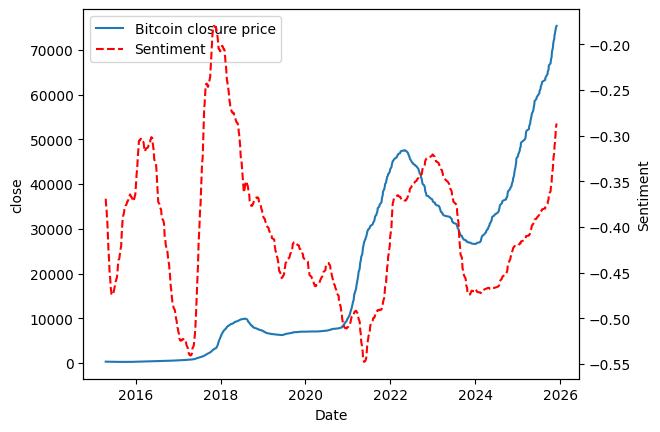

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

btc.index = pd.to_datetime(btc.index)
window = 180  # ~6 meses

# --------------------------------  GRÁFICO: --------------------------------------------
volume_smooth = btc['close'].rolling(window).mean() # aqui dá pra mudar com a coluna que a gente quer que relacione com o sentimento no mesmo dia.
sentiment_smooth = btc['sentiment'].rolling(window).mean()

# Figura e eixo principal (Volume)
fig, ax1 = plt.subplots()

ax1.plot(btc.index, volume_smooth, label='Bitcoin closure price')
ax1.set_xlabel('Date')
ax1.set_ylabel('close') # aqui dá pra mudar com a coluna que a gente quer que relacione com o sentimento no mesmo dia.
ax1.tick_params(axis='y')

# Eixo secundário (Sentiment)
ax2 = ax1.twinx()
ax2.plot(
    btc.index,
    sentiment_smooth,
    label='Sentiment',
    linestyle='--',
    color='red'
)
ax2.set_ylabel('Sentiment')
ax2.tick_params(axis='y')


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()


In [16]:
btc["target"] = (btc["tomorrow"] > btc["close"]).astype(int) # 1 se o preço subir amanhã, 0 se cair ou ficar igual

In [17]:
btc["target"].value_counts() # vamos só ver quantos 1s e 0s temos

target
1    932
0    811
Name: count, dtype: int64

Agora: construção do modelo de predição

In [18]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


Vamos criar um modelo "baseline" (modelo básico e "burro" para vermos como estão os hiperparâmetros)

In [22]:
from sklearn.ensemble import RandomForestClassifier # vamos usar random forest como baseline porque é simples, funciona bem e é difícil de overfittar
# Overfitting é quando o modelo aprende tão bem os dados de treino que não consegue generalizar para novos dados.

modelo = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1) 
# n_estimators é o número de árvores na floresta. A gente limita isso para evitar overfitting, porque se ele tiver muitas árvores, ele pode acabar decorando os dados de treino, e não aprendendo os padrões gerais.
# min_samples_split é o número mínimo de amostras necessárias para dividir um nó. A gente aumenta isso para evitar que as árvores cresçam demais (também para evitar overfitting).
# random_state é para garantir que os resultados sejam reproduzíveis. A gente define um valor fixo para que toda vez que rodar o código, obtenha os mesmos resultados.

# vamos separar os dados em treino e teste:
train = btc.iloc[:-200] # usar os últimos 200 dias como teste
test = btc[-200:]

# é importante saber que os dados são série temporais, então não podemos embaralhar os dados antes de dividir em treino e teste. 
# Isso porque queremos prever o futuro com base no passado, então precisamos manter a ordem temporal.
# Usar cross-validation tradicional, por exemplo, não faria sentido, porque ele embaralha os dados.

predictors = ["close", "volume", "open", "high", "low", "edit_count", "sentiment", "neg_sentiment"]
modelo.fit(train[predictors], train["target"]) # treinar o modelo


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,50
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
from sklearn.metrics import precision_score # vamos avaliar a precisão do modelo (%)

preds = modelo.predict(test[predictors]) # fazer previsões no conjunto de teste
preds = pd.Series(preds, index=test.index) # converter para Series do pandas para facilitar a manipulação
precision_score(test["target"], preds) # calcular a precisão das previsões e visualizar

0.5952380952380952

^ Isso foi a nosso baseline. O modelo burro pra começarmos a ver como funcianam os hiperparâmetros desse dataset específico.

In [24]:
# Vamos criar uma função de backtest.
# Antes da função, vamos criar uma outra função (predict) que retorna os resultados combinados de previsões e valores reais, pra facilitar a visualização depois.

def predict(train, test, predictores, model): # criar uma função que recebe os dados de treino, teste, os preditores e o modelo
    model.fit(train[predictors], train["target"])
    preds = model.predict(test[predictors]) # fazer previsões no conjunto de teste
    preds = pd.Series(preds, index=test.index, name = "predictions") # converter para Series do pandas para facilitar a manipulação. 
    # test.index é para manter o índice (colunas) original do conjunto de teste
    combined = pd.concat([test["target"], preds], axis=1) # concatenar as previsões com os valores reais ao longo das colunas (axis=1)
    return combined # combinar as previsões com os valores reais e retornar
    

In [25]:
# O backtesting é uma técnica usada para avaliar a performance de um modelo preditivo usando dados históricos. 
# A ideia é simular como o modelo teria se saído se tivesse sido usado no passado, dividindo os dados em janelas de treino e teste ao longo do tempo.
# Isso é especialmente importante em séries temporais, onde a ordem dos dados é crucial.

# o backtesting vai dizer algo como "Vamos pegar os dados de 2014 a 2017 e usar para prever os de 2018, depois pegar os dados de 2014 a 2018 para prever os de 2019, e assim por diante".
def backtest(data, model, predictions, start=1095, step=150):
    # data é o dataframe completo (btc)
    # model é o modelo de machine learning (random forest) que criamos agorinha
    # predictors são as colunas que vamos usar como preditores
    # start é o ponto inicial para começar o backtest (aqui estamos começando 3 anos atrás). Isso é para garantir que temos dados suficientes para treinar o modelo antes de começar a fazer previsões.
    # step é o tamanho de cada janela de teste (aqui estamos usando 150 dias). Isso significa que a cada iteração, vamos avançar 150 dias e fazer previsões para os próximos 150 dias.
    all_predictions = [] # lista com as previsões
    
    for i in range(start, data.shape[0], step): # loop que vai de 'start' até o final dos dados, avançando 'step' a cada iteração
        # data.shape[0] é pra pegar o número total de linhas no dataframe (número de dias)
        train = data.iloc[0:i].copy() 
        # data.iloc[0:i] pega todas as linhas desde o início até a linha i (exclusivo). Isso é o conjunto de treino.
        # a gente faz uma cópia com .copy() para evitar problemas de SettingWithCopyWarning do pandas, que acontece quando tentamos modificar uma fatia de um dataframe.
        test = data.iloc[i:i+step].copy()
        
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions) # juntar as previsões na lista
    return pd.concat(all_predictions)

In [26]:
#vamos ver o que fizemos então:
visualizar = backtest(btc, modelo, predictors)
visualizar

,target,predictions
2019-06-21 00:00:00+00:00,1,1
2019-06-26 00:00:00+00:00,0,1
2019-06-30 00:00:00+00:00,0,1
2019-07-01 00:00:00+00:00,1,1
2019-07-02 00:00:00+00:00,1,1
...,...,...
2025-11-18 00:00:00+00:00,0,1
2025-11-22 00:00:00+00:00,1,0
2025-11-23 00:00:00+00:00,1,0
2025-11-26 00:00:00+00:00,0,1


Vamos fazer um upgrade do nosso modelo, porque ele até agora é so o básico.
Vamos usar o XGBoost Classifier, que é um método mais poderoso

```
O XGBoost (Extreme Gradient Boosting) é uma biblioteca de aprendizado de máquina otimizada que implementa o algoritmo de boosting de gradiente.

É amplamente utilizado para tarefas de classificação e regressão devido à sua eficiência, desempenho e capacidade de lidar com grandes conjuntos de dados.

Ele funciona construindo uma série de árvores de decisão, onde cada árvore tenta corrigir os erros da árvore anterior.
```

In [ ]:
!pip install xgboost 
# instalando o xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
    --------------------------------------- 1.6/72.0 MB 6.2 MB/s eta 0:00:12
   - -------------------------------------- 2.6/72.0 MB 5.8 MB/s eta 0:00:13
   -- ------------------------------------- 3.9/72.0 MB 5.9 MB/s eta 0:00:12
   -- ------------------------------------- 5.2/72.0 MB 6.0 MB/s eta 0:00:12
   --- ------------------------------------ 6.6/72.0 MB 6.1 MB/s eta 0:00:11
   ---- ----------------------------------- 7.6/72.0 MB 6.0 MB/s eta 0:00:11
   ---- ----------------------------------- 8.7/72.0 MB 5.8 MB/s eta 0:00:11
   ----- ---------------------------------- 10.0/72.0 MB 5.9 MB/s eta 0:00:11
   ------ --------------------------------- 11.3/72.0 MB 6.0 MB/s eta 0:00:11
   ------ --------------------------------- 12.6/72.0 MB 6.0 MB/s eta 0:00:10
   ------

In [27]:
from xgboost import XGBClassifier
# dentro do xgboost, vamos usar o XGBClassifier, que é um classificador baseado em árvores de decisão, é parecido com o random forest, mas geralmente mais poderoso e eficiente.
model = XGBClassifier(random_state=1, learning_rate=.1, n_estimators=300)
    # random_state ainda é a mesma coisa: garantir que os resultados sejam reproduzíveis.
    # learning_rate é a taxa de aprendizado, que controla o quanto o modelo ajusta os pesos a cada iteração. Um valor menor significa que o modelo aprende mais devagar, o que pode ajudar a evitar overfitting.
    # n_estimators é o número de árvores na floresta. A gente aumenta isso porque o xgboost é eficiente e pode lidar com muitas árvores sem overfitting facilmente.
predictions = backtest(btc, model, predictors)

Beleza, avaliando novamente a taxa de precisão do modelo:

In [28]:
precision_score(predictions["target"], predictions["predictions"])

0.5213675213675214

Dá pra ver que a precisão diminuiu, o que é incomum na verdade. Mas isso pode ser porque o modelo está mais conservador, ou seja, ele pode estar prevendo menos altas para evitar falsos positivos.

Pra melhorar isso, podemos ajustar os hiperparâmetros do modelo, como a taxa de aprendizado (learning_rate) ou o número de estimadores (n_estimators), ou até mesmo experimentar outros modelos de machine learning.

O que faremos a seguir: usar trends e médias móveis como preditores adicionais.

In [29]:
# vamos lá, criar mais preditores baseados em médias móveis (rolling averages) para tentar melhorar o modelo.
# Médias móveis são médias calculadas ao longo de uma janela de tempo específica, que ajudam a suavizar as flutuações de curto prazo e destacar tendências de longo prazo nos dados.

# Matematicamente, a fórmula para a média móvel é dada por: 
# MMA_t = (P_t + P_(t-1) + ... + P_(t-n+1)) / n
# onde MMA_t é a média móvel no tempo t, P_t é o preço no tempo t, e n é o número de períodos na janela.

def compute_rolling(btc):
    # essa função vai achar varias trends (médias móveis) para diferentes horizontes de tempo e adicionar como novas colunas no dataframe
    horizons = [2,7,60,365] # esses são os horizontes de tempo que vamos usar para calcular as médias móveis. 
    # Esses valores são os valores padrão do mercado financeiro (2 dias para curto prazo, 7 dias para semanal, 60 dias para trimestral, 365 dias para anual)
    new_predictors = ["close", "sentiment", "neg_sentiment"]
    # Os new_predictors são os mesmos de antes mas vamos basear eles nas médias móveis que vamos calcular agora.
    
    for horizon in horizons:
        rolling_avarages = btc.rolling(horizon, min_periods=1).mean() # dataframe que vai armazenar as médias móveis para o horizonte atual
        # min_periods vai dizer tipo: "mesmo se você tiver só 1 dia de dados, calcula a média móvel assim mesmo". Isso é pra evitar NaNs no começo dos dados.
        ration_column = f"close_ratio_{horizon}" # nome da nova coluna para a razão do preço de fechamento em relação à média móvel
        btc[ration_column] = btc["close"] / rolling_avarages["close"] # colocar os valores na ratio(column)
        
        edit_column = f"edit_count_{horizon}" 
        btc[edit_column] = rolling_avarages["edit_count"]
        
        rolling = btc.rolling(horizon, closed="left", min_periods=1).mean()
        # closed="left" significa que a média móvel não inclui o valor do dia atual, apenas os anteriores. 
        # Isso é importante para evitar vazamento de dados (data leakage), onde informações do futuro influenciam o cálculo do presente.
        trend_column = f"trend_{horizon}"
        btc[trend_column] = rolling["target"]
        
        new_predictors += [ration_column, trend_column, edit_column]
    return btc, new_predictors

btc, new_predictors = compute_rolling(btc.copy()) # vamos fazer uma cópia do dataframe original para evitar modificar os dados dele

In [30]:
btc

,open,high,low,close,volume,edit_count,sentiment,neg_sentiment,tomorrow,target,...,trend_2,close_ratio_7,edit_count_7,trend_7,close_ratio_60,edit_count_60,trend_60,close_ratio_365,edit_count_365,trend_365
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,1.0,-0.174351,0.566667,424.440002,0,...,NaN,1.000000,1.0,NaN,1.000000,1.0,NaN,1.000000,1.0,NaN
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,1.0,-0.174023,0.566667,394.795990,0,...,0.0,0.962696,1.0,0.000000,0.962696,1.0,0.000000,0.962696,1.0,0.000000
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,1.0,-0.172224,0.566667,408.903992,1,...,0.0,0.927789,1.0,0.000000,0.927789,1.0,0.000000,0.927789,1.0,0.000000
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,1.0,-0.166161,0.566667,398.821014,0,...,0.5,0.970419,1.0,0.333333,0.970419,1.0,0.333333,0.970419,1.0,0.333333
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,1.0,-0.108003,0.533333,435.790985,1,...,0.5,0.956729,1.0,0.250000,0.956729,1.0,0.250000,0.956729,1.0,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-18 00:00:00+00:00,92094.531250,93745.078125,89300.460938,92948.875000,101333569062,1.0,0.216875,0.366667,84648.359375,0,...,0.5,0.933155,1.0,0.285714,0.912316,1.0,0.500000,1.829625,1.0,0.501370
2025-11-22 00:00:00+00:00,85098.562500,85503.007812,83490.898438,84648.359375,40793099246,1.0,0.282193,0.333333,86805.007812,1,...,0.5,0.877379,1.0,0.285714,0.833118,1.0,0.500000,1.662834,1.0,0.501370
2025-11-23 00:00:00+00:00,84648.609375,88038.468750,84641.773438,86805.007812,58083435576,1.0,0.216004,0.366667,90518.367188,1,...,0.5,0.919469,1.0,0.428571,0.855857,1.0,0.516667,1.701703,1.0,0.501370
2025-11-26 00:00:00+00:00,87345.585938,90581.156250,86316.898438,90518.367188,66496301869,1.0,0.222128,0.366667,86321.570312,0,...,1.0,0.977256,1.0,0.428571,0.891816,1.0,0.533333,1.770706,1.0,0.501370


In [31]:
# com as novas features criadas, vamos rodar o backtest de novo com o xgboost
predictions = backtest(btc, model, new_predictors)

Beleza agora vamos ver a taxa de acertos novamente:

In [32]:
precision_score(predictions["target"], predictions["predictions"])

0.5213675213675214

In [33]:
predictions

,target,predictions
2019-06-21 00:00:00+00:00,1,1
2019-06-26 00:00:00+00:00,0,1
2019-06-30 00:00:00+00:00,0,0
2019-07-01 00:00:00+00:00,1,1
2019-07-02 00:00:00+00:00,1,1
...,...,...
2025-11-18 00:00:00+00:00,0,0
2025-11-22 00:00:00+00:00,1,0
2025-11-23 00:00:00+00:00,1,1
2025-11-26 00:00:00+00:00,0,0


Vemos que mesmo com as novas features, a precisão do modelo não melhorou muito.



Para resolver isso, poderíamos tentar outras abordagens, como ajustar os hiperparâmetros do modelo, experimentar diferentes algoritmos de machine learning, ou até mesmo criar novas features baseadas em outros aspectos dos dados.


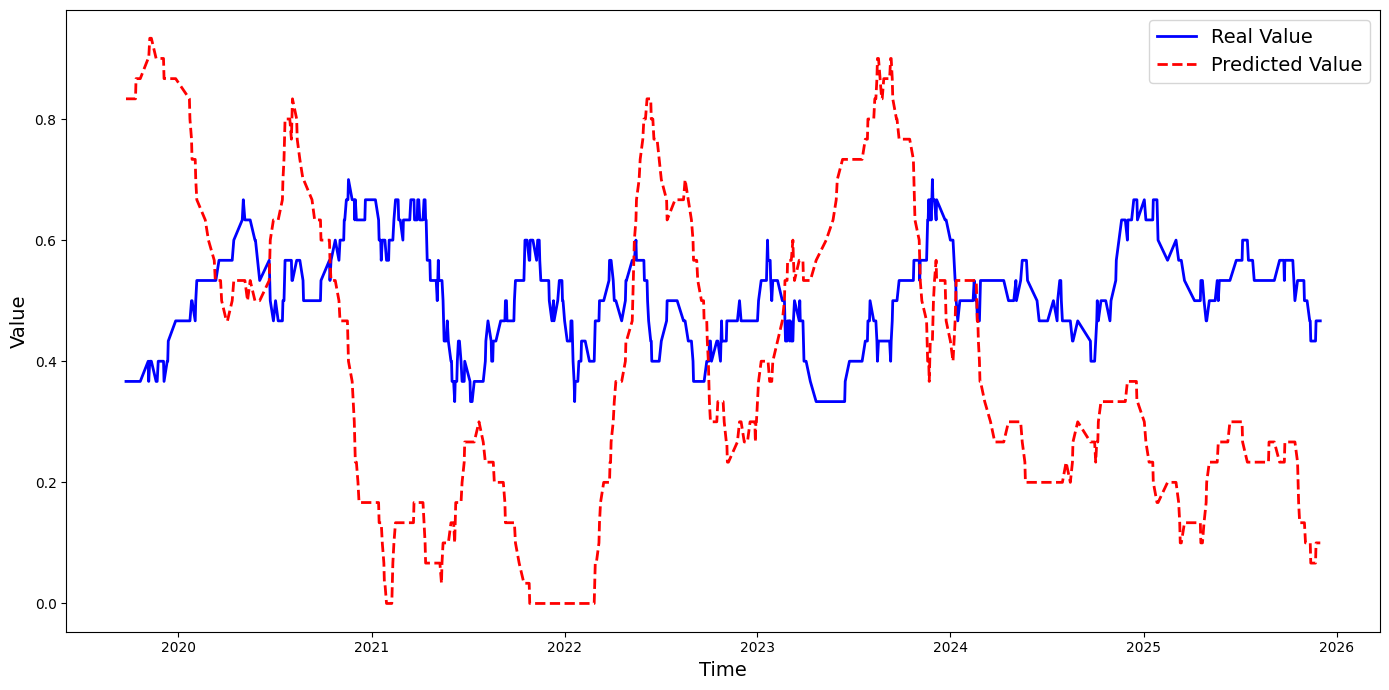

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# garantir índice datetime
predictions = predictions.copy()
predictions.index = pd.to_datetime(predictions.index)

# suavização no dataset inteiro
real_smooth = predictions["target"].rolling(30).mean()
pred_smooth = predictions["predictions"].rolling(30).mean()

# plot
plt.figure(figsize=(14, 7))

plt.plot(
    real_smooth,
    label="Real Value",
    linewidth=2,
    color='blue'
)

plt.plot(
    pred_smooth,
    label="Predicted Value",
    linestyle="--",
    linewidth=2,
    color='red'
)

plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# garantir datetime
predictions = predictions.copy()
predictions.index = pd.to_datetime(predictions.index)

# erro quadrático
predictions["squared_error"] = (predictions["target"] - predictions["predictions"]) ** 2


In [36]:

mse_ma30 = predictions["squared_error"].rolling(90).mean()


In [37]:
end_date = predictions.index.max()
start_date = end_date - pd.DateOffset(years=1)

mse_last_year = mse_ma30.loc[start_date:end_date]


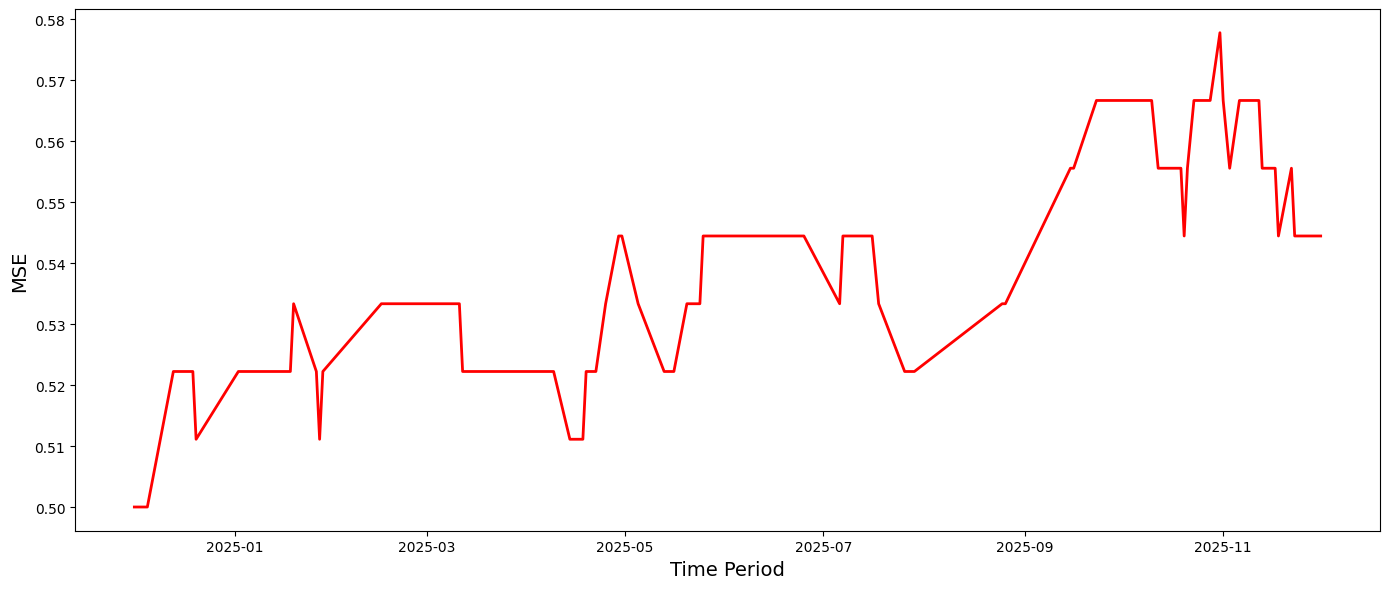

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(
    mse_last_year,
    linewidth=2,
    color="red",
)

plt.xlabel("Time Period", fontsize = 14)
plt.ylabel("MSE", fontsize = 14)
plt.tight_layout()
plt.show()


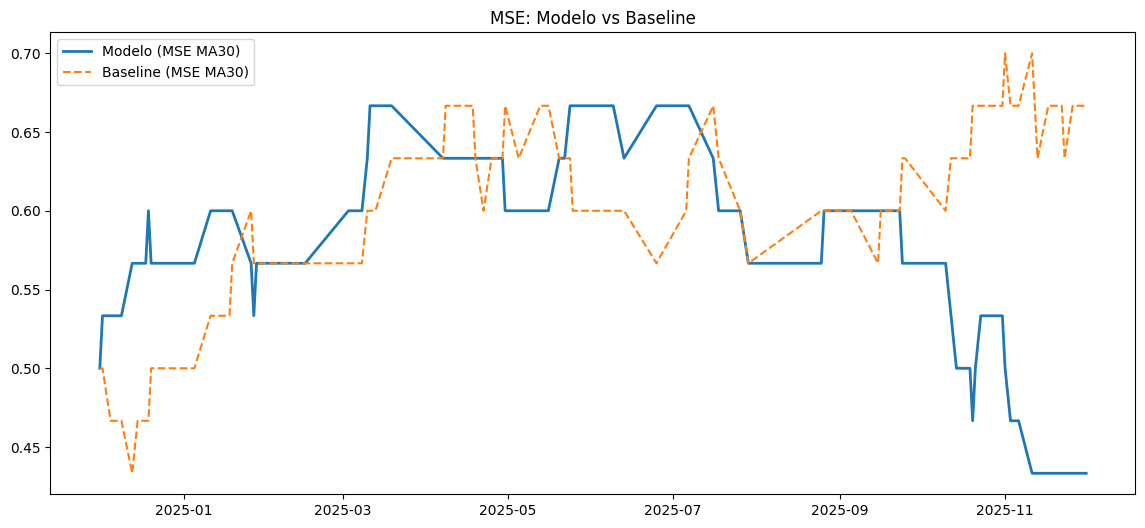

In [ ]:
baseline_pred = predictions["target"].shift(1)
baseline_mse = ((predictions["target"] - baseline_pred) ** 2).rolling(30).mean()

baseline_last_year = baseline_mse.loc[start_date:end_date]

plt.figure(figsize=(14, 6))

plt.plot(mse_last_year, label="Modelo (MSE MA30)", linewidth=2)
plt.plot(baseline_last_year, label="Baseline (MSE MA30)", linestyle="--")

plt.title("MSE: Modelo vs Baseline")
plt.legend()
plt.show()
